In [1]:
import os
import sys
import numpy as np
import torch as th
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import imageio
from pathlib import Path
import math
from datetime import datetime

# Add the root directory to the path
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "."))

# Add splatter-image path
SPLATTER_IMAGE_ROOT = os.environ.get("SPLATTER_IMAGE_ROOT", "/om/user/akiruga/splatter-image")
sys.path.append(SPLATTER_IMAGE_ROOT)
sys.path.append(os.path.join(SPLATTER_IMAGE_ROOT, "experiments/voxel-optimization"))

# Add svox2 path
SVOX2_ROOT = "/om/user/akiruga/svox2"
sys.path.append(SVOX2_ROOT)
sys.path.append(os.path.join(SVOX2_ROOT, "opt"))


import_path_1 = "/om/user/akiruga/diffsplatimg3d/scripts"
import_path_2 = "/om/user/akiruga/splatter-image/experiments/voxel-optimization"
import_path_3 = "/om/user/akiruga/svox2/opt"

sys.path.append(import_path_1)
sys.path.append(import_path_2)
sys.path.append(import_path_3)

print("Imports successful")


Imports successful


In [2]:
from guided_diffusion import dist_util, logger
from guided_diffusion.resample import create_named_schedule_sampler
from guided_diffusion.script_util_3d import (
    model_and_diffusion_defaults_3d,
    create_model_and_diffusion_3d,
    args_to_dict,
    add_dict_to_argparser,
    str2bool,
)

N_CH = 4  # 1 density + 3 SH channels
EPS = 1e-12

loading the data

In [3]:
def load_zscore_stats(stats_path):
    """Load z-score normalization statistics"""
    if not os.path.exists(stats_path):
        raise FileNotFoundError(f"Z-score stats not found: {stats_path}")
    
    stats = th.load(stats_path)
    return stats

In [4]:
data_dir =  Path("/weka/scratch/weka/tenenbaum/akiruga/svox2/data/ckpts/shapenet_chairs_all_jupyter")
# norm_stats_path = Path("/om/user/akiruga/diffsplatimg3d/bespoke_norm_stats.pt")
norm_stats_path = Path("/om/user/akiruga/diffsplatimg3d/zscore_norm_stats.pt")


In [6]:
def zscore_normalize(grid_tensor, stats):
    """
    Normalize a plenoxel grid using z-score standardization
    
    Args:
        grid_tensor: [D, H, W, C] tensor with 4 channels
        stats: dict with 'mean' and 'std' tensors
    
    Returns:
        normalized tensor with zero mean and unit variance per channel
    """
    # print("using z-score normalization")
    mean = stats["mean"].to(grid_tensor.device)
    std = stats["std"].to(grid_tensor.device)
    
    g = grid_tensor.view(-1, N_CH).clone()
    # For density channel, add offset to counteract training code offset
    # g[:, 0] += 25
    g = (g - mean) / (std + EPS)
    
    return g.view_as(grid_tensor)

def zscore_denormalize(norm_grid, stats):
    """
    Denormalize a z-score normalized plenoxel grid
    
    Args:
        norm_grid: normalized tensor with zero mean and unit variance
        stats: dict with 'mean' and 'std' tensors
    
    Returns:
        denormalized tensor in original scale
    """
    # print("using z-score denormalization")
    mean = stats["mean"].to(norm_grid.device)
    std = stats["std"].to(norm_grid.device)
    
    g = norm_grid.view(-1, N_CH).clone()
    g = g * (std + EPS) + mean
    # For density channel, subtract offset to counteract training code offset
    # g[:, 0] -= 25
    
    return g.view_as(norm_grid)



In [7]:
class PlenoxelDataset(th.utils.data.Dataset):
    """
    Dataset for loading dense_grid.npz files from svox2 optimization
    Applies z-score normalization as in jupyter code
    """
    
    def __init__(self, data_dir, norm_stats_path, grid_size=32):
        self.data_dir = Path(data_dir)
        self.grid_size = grid_size
        
        # Load z-score normalization stats
        self.stats = load_zscore_stats(norm_stats_path)
        
        # Find all dense_grid.npz files
        self.file_paths = sorted(list(self.data_dir.rglob("dense_grid.npz")))
        
        if len(self.file_paths) == 0:
            raise ValueError(f"No dense_grid.npz files found in {data_dir}")
        
        print(f"Found {len(self.file_paths)} plenoxel files in {data_dir}")
        
        # Verify shapes
        sample_data = np.load(self.file_paths[0])
        sample_grid = sample_data["dense_grid"]
        print(f"Sample grid shape: {sample_grid.shape}")
        
        if sample_grid.shape != (grid_size, grid_size, grid_size, 4):
            raise ValueError(f"Expected shape ({grid_size}, {grid_size}, {grid_size}, 4), got {sample_grid.shape}")
    
    def __len__(self):
        return len(self.file_paths)
    
    def __getitem__(self, idx):
        # Load dense grid
        file_path = self.file_paths[idx]
        data = np.load(file_path)
        dense_grid = th.from_numpy(data["dense_grid"]).float()  # [D, H, W, C]
        
        
        # Normalize using z-score standardization
        normalized_grid = zscore_normalize(dense_grid, self.stats)
        
        # Convert to [C, D, H, W] format for 3D convolution
        normalized_grid = normalized_grid.permute(3, 0, 1, 2)
        
        return normalized_grid, str(file_path)


In [9]:
def custom_collate_fn(batch):
    """Custom collate function to handle (data, file_path) tuples"""
    data_tensors = []
    file_paths = []
    
    for data, file_path in batch:
        data_tensors.append(data)
        file_paths.append(file_path)
    
    # Stack data tensors into a batch
    batch_data = th.stack(data_tensors, dim=0)
    
    return batch_data, file_paths


dataset = PlenoxelDataset(
        data_dir=data_dir,
        norm_stats_path=norm_stats_path,
        grid_size=32,
    )
loader = th.utils.data.DataLoader(
                dataset, batch_size=1,
                drop_last=True, collate_fn=custom_collate_fn
            )

for i, (data, file_path) in enumerate(loader):
    print(data.shape)
    print(file_path)
    break

Found 1980 plenoxel files in /weka/scratch/weka/tenenbaum/akiruga/svox2/data/ckpts/shapenet_chairs_all_jupyter
Sample grid shape: (32, 32, 32, 4)
torch.Size([1, 4, 32, 32, 32])
['/weka/scratch/weka/tenenbaum/akiruga/svox2/data/ckpts/shapenet_chairs_all_jupyter/1006be65e7bc937e9141f9b58470d646/dense_grid.npz']


In [10]:
stats = load_zscore_stats(norm_stats_path)

load the model 

OPENAI_LOGDIR=/om/user/akiruga/diffsplatimg3d/checkpoint/bespoke-z-norm-linear-schedule nohup python scripts/voxel_gaussian_train_plenoxels.py \
    --data_dir "/weka/scratch/weka/tenenbaum/akiruga/svox2/data/ckpts/shapenet_chairs_all_jupyter" \
    --norm_stats_path "/om/user/akiruga/diffsplatimg3d/bespoke_norm_stats.pt" \
    --wandb_project "plenoxels-diffusion" \
    --wandb_run "bespoke-z-norm-linear-schedule" \
    --batch_size 52 \
    --lr 1e-4 \
    --max_steps 1000000 \
    --volume_size 32 \
    --use_checkpoint True \
    --use_scale_shift_norm True\
    --log_interval 200 \
    --test_generation_interval 200 \
    --save_interval 1000 > nohup_out/voxel_gaussian_train_plenoxels_bespoke_z-norm_linear_schedule.out 2>&1 &


In [38]:
model, diffusion = create_model_and_diffusion_3d(
        volume_size=32,
        in_channels=4,  # 1 density + 3 SH
        out_channels=4,  # Same as input (no learned sigma by default)
        num_classes=None,
        dropout=0.0,
        use_checkpoint=False,
        use_fp16=False, 
        use_scale_shift_norm=True,
        resblock_updown=False,
        use_new_attention_order=False,
        learn_sigma=False,
        diffusion_steps=1000,
        noise_schedule="linear",
        # noise_schedule="cosine",
        timestep_respacing="",
        use_kl=False,
        predict_xstart=False,
        rescale_timesteps=False,
        rescale_learned_sigmas=False,
    )

In [39]:
# Set up distributed training for single process
import os
import torch.distributed as dist
from guided_diffusion import dist_util

# Set environment variables for single-process distributed
os.environ['MASTER_ADDR'] = 'localhost'
os.environ['MASTER_PORT'] = '12355'
os.environ['RANK'] = '0'
os.environ['WORLD_SIZE'] = '1'
os.environ['LOCAL_RANK'] = '0'
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ['group_size'] = '1'
# Use the guided_diffusion setup function
dist_util.setup_dist()

# DON'T DELETE THIS CODEBLOCK. IT WORKS SOMEHOW DESPITE THE ERROR

In [40]:
from guided_diffusion.train_util import TrainLoop
from guided_diffusion.resample import create_named_schedule_sampler
import guided_diffusion.dist_util as dist_util

# Patch the sync_params function to be a no-op in notebook
def no_op_sync_params(params):
    pass

dist_util.sync_params = no_op_sync_params
device = dist_util.dev()  # This returns the correct device
model = model.to(device)

schedule_sampler = create_named_schedule_sampler("uniform", diffusion)

train_loop = TrainLoop(
        model=model,
        diffusion=diffusion,
        data=loader,
        batch_size=1,
        microbatch=1,
        lr=1e-4,
        ema_rate="0.9999",
        log_interval=10,
        save_interval=1000,
        resume_checkpoint="",
        use_fp16=False,
        fp16_scale_growth=1e-3,
        schedule_sampler=schedule_sampler,
        weight_decay=0.0,
        lr_anneal_steps=3000000,
    )

## visualizations + debugging

In [41]:
!pwd

/om/user/akiruga/diffsplatimg3d


In [42]:
import svox2
def render_plenoxel_video(dense_grid, cameras, fps=12, crop=1.0, save_video=True, video_prefix="render"):
    """
    Render video from dense plenoxel grid and return frames for logging
    Adapted from opt.ipynb Cell 2 and plenoxels_utils.py render_video
    """
    
    # Ensure everything is on CUDA
    device = th.device("cuda" if th.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    print(f"Input dense_grid device: {dense_grid.device}")
    
    # Move dense_grid to CUDA if it's not already
    if dense_grid.device != device:
        print(f"Moving dense_grid from {dense_grid.device} to {device}")
        dense_grid = dense_grid.to(device)
    
    # Convert to sparse grid
    grid = dense_to_sparsegrid(dense_grid, device=device)
    grid.eval()
    
    print(f"Grid device after creation: {grid.density_data.device}")
    print(f"REFERENCE_GRID device: {REFERENCE_GRID.density_data.device}")
    
    frames = []
    with th.no_grad():
        for cam in cameras:
            # Optional center-crop so you can render faster mid-training
            w, h = cam.width, cam.height
            if crop < 1.0:
                cam = svox2.Camera(
                    cam.c2w, cam.fx, cam.fy,
                    cam.cx * crop, cam.cy * crop,
                    int(w * crop), int(h * crop),
                    ndc_coeffs=cam.ndc_coeffs
                )
            im = grid.volume_render_image(cam, use_kernel=True)
            im = (im.clamp(0, 1).cpu().numpy() * 255).astype(np.uint8)
            frames.append(im)
    
    # Save video file if requested
    if save_video and len(frames) > 0:
        debug_dir = Path(LOG_PATH) / "debug_images"
        debug_dir.mkdir(exist_ok=True)
        video_path = debug_dir / f"{video_prefix}_video.mp4"
        imageio.mimwrite(str(video_path), frames, fps=fps, macro_block_size=8)
        print(f"✔️  Saved preview video → {video_path}")
    
    grid.train()
    return frames

def dense_to_sparsegrid(
        dense_grid: th.Tensor,
        device: th.device = None
    ) -> svox2.SparseGrid:
    """
    Reconstruct a fully–dense SparseGrid from a dense tensor.

    Args
    ----
    dense_grid : (X, Y, Z, 4) tensor
        Channel 0 = density, 1-3 = SH coefficients (flattened RGB·basis_dim).
    template_grid : SparseGrid
        Any existing grid whose radius/center/render‑opts you want to clone.
    device : torch.device, optional
        Target device. Defaults to template_grid’s device.

    Returns
    -------
    new_grid : SparseGrid
        A grid ready to be used with all rendering functions.
    """
    template_grid = REFERENCE_GRID
    if device is None:
        device = dense_grid.device

    # ── sizes ────────────────────────────────────────────────────────────────────
    X, Y, Z, C = dense_grid.shape
    basis_dim = (C - 1) // 3

    # ── flatten & split ─────────────────────────────────────────────────────────
    flat = dense_grid.view(-1, C)               # (N, C)  where N = X*Y*Z
    density_data = flat[:, :1].contiguous()     # (N, 1)
    sh_data      = flat[:, 1:].contiguous()     # (N, basis_dim*3)

    # ── make a brand‑new SparseGrid with identical meta‑data ────────────────────
    new_grid = svox2.SparseGrid(
        reso=(X, Y, Z),
        radius=template_grid.radius.tolist(),
        center=template_grid.center.tolist(),
        basis_type=svox2.BASIS_TYPE_SH,
        basis_dim=basis_dim,
        use_z_order=False,
        device=device,
    )

    # overwrite internal tensors
    new_grid.density_data = nn.Parameter(density_data.to(device))
    new_grid.sh_data      = nn.Parameter(sh_data.to(device))

    # every voxel is active → simple dense mapping
    n_vox = X * Y * Z
    new_grid.links = th.arange(
        n_vox, dtype=th.int32, device=device).view(X, Y, Z)
    new_grid.capacity = n_vox

    # optional: accelerate for CUDA ray‑march kernels
    if new_grid.links.is_cuda:
        new_grid.accelerate()

    # copy render options (step size, background, etc.)
    new_grid.opt = template_grid.opt

    return new_grid

In [43]:
from plenoxels_utils import get_reference_grid
from plenoxels_utils import render_video
import svox2
REFERENCE_GRID, RESAMPLE_CAMERAS = get_reference_grid()
LOG_PATH = "no_git/debug_diff_training"
os.makedirs(LOG_PATH, exist_ok=True)
assert REFERENCE_GRID is not None, "Reference grid not found"
def log_plenoxel_viz(volume, prefix, stats, is_noise=False, source_file_path=None, timestep=None, do_not_save=False):
    """Log visualization of a plenoxel volume with rendering"""
    
    volume = volume.detach().clone()  # [C, D, H, W]
    
    try:
        print(f"=== LOGGING {prefix} ===")
        if timestep is not None:
            print(f"Timestep: {timestep} (higher = more noisy)")
        print(f"Volume shape: {volume.shape}")
        print(f"Volume device: {volume.device}")
        print(f"Volume range: [{volume.min().item():.3f}, {volume.max().item():.3f}]")
        
        # Convert to [D, H, W, C] for denormalization and rendering
        volume_dhwc = volume.permute(1, 2, 3, 0)  # [D, H, W, C]
        
        if not is_noise:
            # Denormalize for rendering
            denorm_volume = zscore_denormalize(volume_dhwc, stats)
            print(f"Denormalized range: [{denorm_volume.min().item():.3f}, {denorm_volume.max().item():.3f}]")
        else:
            # For noise, use raw volume (already in correct format for rendering)
            denorm_volume = volume_dhwc
        
        # Render video frames using multiple camera views
        # num_views = min(12, len(RESAMPLE_CAMERAS))  # Use up to 12 views
        num_views = len(RESAMPLE_CAMERAS)
        # Include timestep in filename if provided
        filename_base = f"{prefix.replace('/', '_')}"
        if timestep is not None:
            filename_base += f"_t{timestep}"
        
        frames = render_plenoxel_video(
            denorm_volume, 
            RESAMPLE_CAMERAS[:num_views], 
            fps=5, 
            crop=1.0, 
            save_video=True,
            video_prefix=filename_base
        )
        
        if frames and len(frames) > 0 and not do_not_save:
            print(f"Rendered {len(frames)} frames")
            
            # Save debug images locally
            debug_dir = Path(os.path.join(LOG_PATH, "debug_images"))
            debug_dir.mkdir(exist_ok=True)
            
            # Save first few frames
            for i, frame in enumerate(frames[:4]):
                frame_path = debug_dir / f"{filename_base}_frame_{i}.png"
                imageio.imwrite(frame_path, frame)
            
            # Create multiview grid
            grid_size = math.ceil(math.sqrt(len(frames)))
            while len(frames) < grid_size * grid_size:
                frames.append(np.zeros_like(frames[0]))
            
            rows = []
            for i in range(grid_size):
                row_frames = frames[i*grid_size:(i+1)*grid_size]
                rows.append(np.concatenate(row_frames, axis=1))
            multiview_grid = np.concatenate(rows, axis=0)
            
            # Save grid and video
            grid_path = debug_dir / f"{filename_base}_grid.png"
            imageio.imwrite(grid_path, multiview_grid)
            
            video_path = debug_dir / f"{filename_base}_video.mp4"
            imageio.mimwrite(video_path, frames, fps=5)
            
            print(f"Saved visualization to {debug_dir}")
            
            # Print specific path for GT data for manual rendering comparison
            if "gt_data" in prefix.lower():
                print(f"📁 SOURCE DENSE_GRID.NPZ FILE: {source_file_path}")
                print(f"🎬 GT VIDEO PATH FOR MANUAL RENDERING: {video_path}")
                print(f"   You can manually render the .npz file to compare rendering quality")
            
    except Exception as e:
        raise e 
    # return the video path and the grid path
    if do_not_save:
        return frames, None
    else:
        return video_path, grid_path

LOAD NSVF DATA /om/user/akiruga/datasets/srn_chairs_alternate_views/feab80af7f3e459120523e15ec10a342/viz split train


  0%|                                                                  | 0/187 [00:00<?, ?it/s]

100%|███████████████████████████████████████████████████████| 187/187 [00:00<00:00, 867.38it/s]


NORMALIZE BY? manual
scene_scale 1.0
 intrinsics (loaded reso) Intrin(fx=131.25, fy=131.25, cx=64.0, cy=64.0)
 Generating rays, scaling factor 1
LOAD NSVF DATA /om/user/akiruga/datasets/srn_chairs_alternate_views/feab80af7f3e459120523e15ec10a342/viz split test


100%|█████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 769.03it/s]


NORMALIZE BY? manual
scene_scale 1.0
 intrinsics (loaded reso) Intrin(fx=131.25, fy=131.25, cx=64.0, cy=64.0)
  FOV: 51.98948897809546 degrees = 0.9073877590970678 radians
  Image size: 128x128
  Calculated focal length: 131.25
  Principal point: (64.0, 64.0)
Calculated optimal center: [-0.00228033  0.00017712  0.00033823]
Calculated optimal radius: [0.44999999999999996, 0.44999999999999996, 0.44999999999999996]
Custom center: [0.0, 0.0, 0.0]
Original dataset center: [0.0, 0.0, 0.0]
Original scene radius: [1.0, 1.0, 1.0]
Scaled scene radius: [0.45, 0.45, 0.45] (scale factor: 0.45)
Render options RenderOptions(backend='cuvol', background_brightness=1.0, step_size=0.5, sigma_thresh=1e-08, stop_thresh=1e-07, last_sample_opaque=False, near_clip=0.0, use_spheric_clip=False, random_sigma_std=0.0, random_sigma_std_background=0.0)
Setting temporary gray density to visualize grid bounds...
✔️  Saved preview video → /om/user/akiruga/svox2/data/ckpts/shapenet_chairs_jupyter/video_00000_bounds.mp4

=== LOGGING before_noise ===
Volume shape: torch.Size([4, 32, 32, 32])
Volume device: cpu
Volume range: [-26.217, 9.169]
Denormalized range: [-1993.111, 521.422]
Using device: cuda
Input dense_grid device: cpu
Moving dense_grid from cpu to cuda
Grid device after creation: cuda:0
REFERENCE_GRID device: cuda:0
✔️  Saved preview video → no_git/debug_diff_training/debug_images/before_noise_video.mp4
Rendered 187 frames
Saved visualization to no_git/debug_diff_training/debug_images


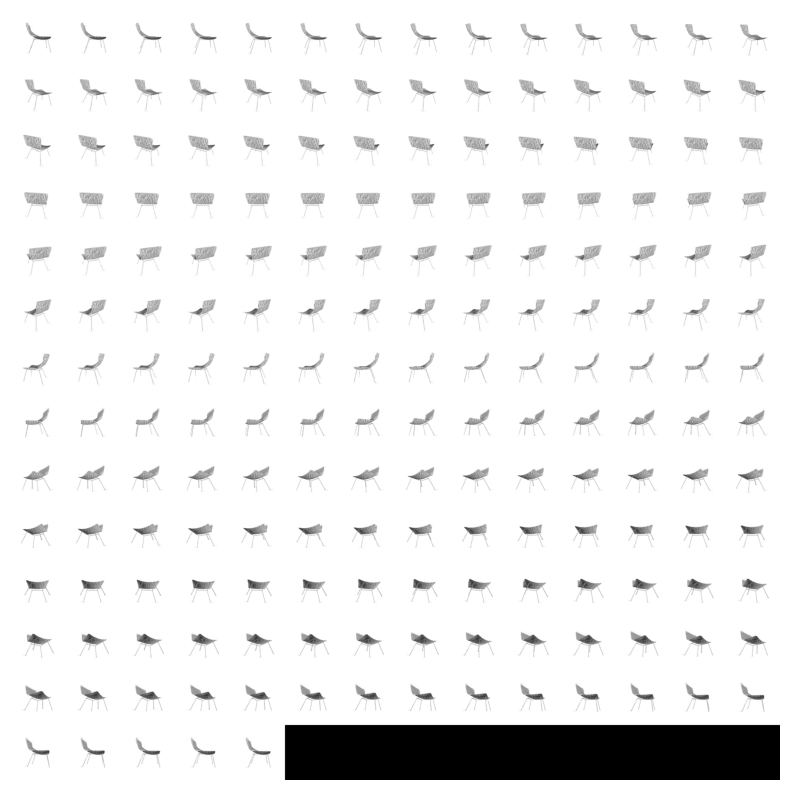

In [44]:
# visualize the ground truth data

cur_data = next(iter(data)).clone().detach()

before_noise_video_path, before_noise_grid_path = log_plenoxel_viz(cur_data, "before_noise", stats)

# show the grid in jupyter notebook
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread(before_noise_grid_path)
plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis('off')
plt.show()
# show the video in jupyter notebook
from IPython.display import Video
Video(before_noise_video_path)



### Run forward noising

In [45]:
import torch as th

noise = th.randn_like(cur_data)
ts = [0, 100, 200, 300, 400, 500, 600, 700, 800, 900]
xts = []
for t in ts:
    t = th.tensor([t])
    x_t = diffusion.q_sample(cur_data, t, noise=noise)
    x_t = x_t.cpu()
    # force density to be 1 
    # x_t[0, :, :, :] = 0.595190211
    # x_t[0, :, :, :] = 0.6
    frames, _ = log_plenoxel_viz(x_t, f"xt_{t.item()}", stats, do_not_save = True)
    
    xts.append(th.tensor(frames[0]))

# visualie the xts in torchgrid 
xt_grid = th.stack(xts).permute(0, 3, 1, 2)











=== LOGGING xt_0 ===
Volume shape: torch.Size([4, 32, 32, 32])
Volume device: cpu
Volume range: [-26.216, 9.173]
Denormalized range: [-1993.023, 521.717]
Using device: cuda
Input dense_grid device: cpu
Moving dense_grid from cpu to cuda
Grid device after creation: cuda:0
REFERENCE_GRID device: cuda:0


✔️  Saved preview video → no_git/debug_diff_training/debug_images/xt_0_video.mp4
=== LOGGING xt_100 ===
Volume shape: torch.Size([4, 32, 32, 32])
Volume device: cpu
Volume range: [-24.808, 8.801]
Denormalized range: [-1888.398, 501.406]
Using device: cuda
Input dense_grid device: cpu
Moving dense_grid from cpu to cuda
Grid device after creation: cuda:0
REFERENCE_GRID device: cuda:0
✔️  Saved preview video → no_git/debug_diff_training/debug_images/xt_100_video.mp4
=== LOGGING xt_200 ===
Volume shape: torch.Size([4, 32, 32, 32])
Volume device: cpu
Volume range: [-21.247, 8.013]
Denormalized range: [-1623.654, 432.971]
Using device: cuda
Input dense_grid device: cpu
Moving dense_grid from cpu to cuda
Grid device after creation: cuda:0
REFERENCE_GRID device: cuda:0
✔️  Saved preview video → no_git/debug_diff_training/debug_images/xt_200_video.mp4
=== LOGGING xt_300 ===
Volume shape: torch.Size([4, 32, 32, 32])
Volume device: cpu
Volume range: [-16.466, 7.138]
Denormalized range: [-1268.258

In [46]:
import torch as th

volume_dhwc = x_t.permute(1, 2, 3, 0)
denorm_volume = zscore_denormalize(volume_dhwc, stats)







In [47]:
stats

{'mean': tensor([-4.4244e+01,  1.8905e-01,  8.8776e-02,  1.7890e-02]),
 'std': tensor([74.3361,  0.5633,  0.6125,  0.6634])}

In [48]:
volume_dhwc[0,0,0,0], denorm_volume[0,0,0,0]

(tensor(0.9293), tensor(24.8395))

In [49]:
x_t.shape

torch.Size([4, 32, 32, 32])

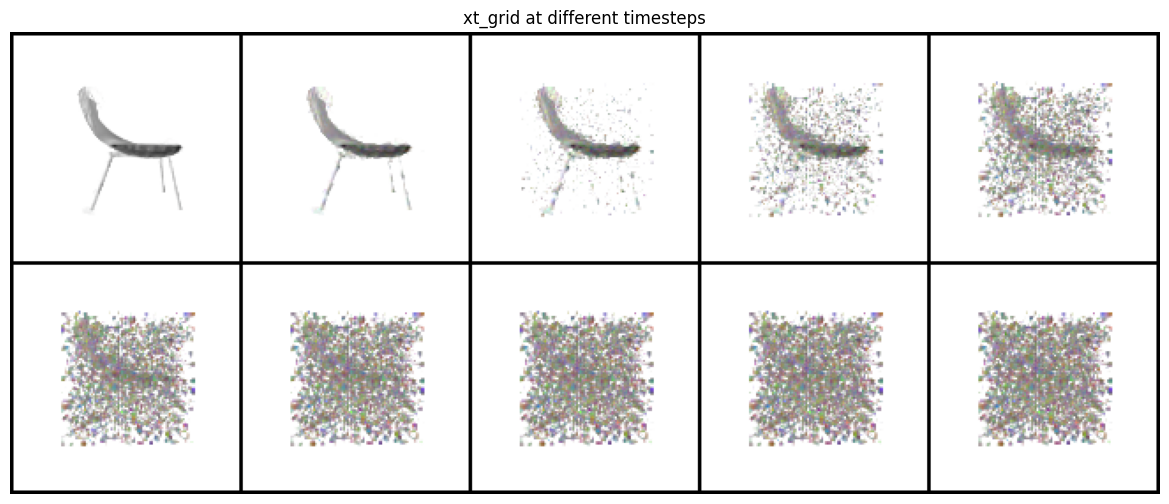

In [50]:

import torchvision

grid_img = torchvision.utils.make_grid(xt_grid, nrow=5, padding=2)

plt.figure(figsize=(15, 6))
plt.imshow(grid_img.permute(1, 2, 0).cpu().numpy())
plt.axis('off')
plt.title("xt_grid at different timesteps")
plt.show()



    





In [51]:
xt_full_noise.shape

NameError: name 'xt_full_noise' is not defined

In [50]:
import matplotlib.pyplot as plt

def plot_density_slice(voxel_grid, depth_idx = 0): 
    # get a numpy array for plotting
    density_frame = voxel_grid[0, :, :, 0].cpu().numpy()

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(density_frame, interpolation='nearest', cmap='viridis')
    ax.axis('off')

    # annotate each cell
    n, m = density_frame.shape
    for i in range(n):
        for j in range(m):
            ax.text(j, i, f"{density_frame[i, j]:.2f}",
                    ha='center', va='center', fontsize=6)

    plt.show()


In [ ]:
# plot a slice of density grid at full noise 
xt_full_noise = diffusion.q_sample(cur_data, th.tensor([999]), noise=noise)

plot_density_slice(xt_full_noise)

# plot a slice of density grid at 0 noise 
xt_0_noise = diffusion.q_sample(cur_data, th.tensor([0]), noise=noise)

plot_density_slice(xt_0_noise, depth_idx = 16)





In [23]:
xt_grid.shape

torch.Size([10, 4, 32, 32, 32])